In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



In [8]:
df = pd.read_csv(r'Y:\Yashas\tk185175 - Performance Analysis of Intrusion Detection Systems\FRONTEND\CODE\DATA SET\UNSW_NB15_training-set.csv')

In [9]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [10]:
df.tail()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
82327,82328,0.000005,udp,-,INT,2,0,104,0,200000.005100,...,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,...,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82331,82332,0.000009,udp,-,INT,2,0,104,0,111111.107200,...,1,1,0,0,0,1,1,0,Normal,0


In [11]:
df.shape

(82332, 45)

In [12]:
df.describe(include='all')

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,82332.000000,82332.000000,82332,82332,82332,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332,82332.000000
unique,NaN,NaN,131,13,7,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,FIN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,43095,47153,39339,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37000,NaN
mean,41166.500000,1.006756,NaN,NaN,NaN,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,...,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,NaN,0.550600
std,23767.345519,4.710444,NaN,NaN,NaN,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,...,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,NaN,0.497436
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,20583.750000,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,NaN,0.000000
50%,41166.500000,0.014138,NaN,NaN,NaN,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,...,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,NaN,1.000000
75%,61749.250000,0.719360,NaN,NaN,NaN,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,...,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,NaN,1.000000


In [13]:
df['attack_cat'].value_counts()

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

In [14]:
82332-37000

45332

In [15]:
df.isnull().sum().sum()

0

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [17]:
df.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [18]:
asdf = ['id','label']

In [19]:
df.drop(asdf,axis=1,inplace=True)

In [20]:
df.shape

(82332, 43)

In [21]:
df['attack_cat'].value_counts()

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

In [22]:
df.replace({'Normal':0,'Generic':1,'Exploits':1,'Fuzzers':1,'DoS':1,'Reconnaissance':1,'Analysis':1,'Backdoor':1,'Shellcode':1,'Worms':1},inplace=True)

C:\Users\1052\AppData\Local\Temp\ipykernel_10056\4084347340.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Normal':0,'Generic':1,'Exploits':1,'Fuzzers':1,'DoS':1,'Reconnaissance':1,'Analysis':1,'Backdoor':1,'Shellcode':1,'Worms':1},inplace=True)


In [23]:
df['attack_cat'].value_counts()

attack_cat
1    45332
0    37000
Name: count, dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dur                82332 non-null  float64
 1   proto              82332 non-null  object 
 2   service            82332 non-null  object 
 3   state              82332 non-null  object 
 4   spkts              82332 non-null  int64  
 5   dpkts              82332 non-null  int64  
 6   sbytes             82332 non-null  int64  
 7   dbytes             82332 non-null  int64  
 8   rate               82332 non-null  float64
 9   sttl               82332 non-null  int64  
 10  dttl               82332 non-null  int64  
 11  sload              82332 non-null  float64
 12  dload              82332 non-null  float64
 13  sloss              82332 non-null  int64  
 14  dloss              82332 non-null  int64  
 15  sinpkt             82332 non-null  float64
 16  dinpkt             823

In [25]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,2,1,3,0,0,0,2,3,0,0


In [26]:
df['service'].value_counts()

service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
dhcp           26
radius          9
irc             5
Name: count, dtype: int64

In [27]:
df.describe(include='all')

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
count,82332.000000,82332,82332,82332,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
unique,NaN,131,13,7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,tcp,-,FIN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,43095,47153,39339,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.006756,NaN,NaN,NaN,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,4.710444,NaN,NaN,NaN,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,0.014138,NaN,NaN,NaN,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,0.719360,NaN,NaN,NaN,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000


In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
dur,82332.0,1.006756e+00,4.710444e+00,0.0,0.000008,1.413800e-02,7.193603e-01,5.999999e+01
spkts,82332.0,1.866647e+01,1.339164e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04
dpkts,82332.0,1.754594e+01,1.155741e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000000,5.340000e+02,1.280000e+03,1.435577e+07
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000000,1.780000e+02,9.560000e+02,1.465753e+07
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606114,2.650177e+03,1.111111e+05,1.000000e+06
sttl,82332.0,1.809677e+02,1.015134e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,82332.0,9.571300e+01,1.166677e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.466797,5.770032e+05,6.514286e+07,5.268000e+09
dload,82332.0,6.305470e+05,2.393001e+06,0.0,0.000000,2.112951e+03,1.585808e+04,2.082111e+07


In [44]:
import pandas as pd
import numpy as np

# Assuming 'df' is your dataframe
print(df.dtypes)  # Check data types of each column






dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_ltm       int64
ct_dst_sport_l

In [45]:
# Drop rows with NaN values (optional, depending on your needs)
df = df.dropna()

In [46]:
# Alternatively, fill NaN values with the mean (optional)
# df = df.fillna(df.mean())

In [47]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])

In [49]:
# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

In [31]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,2,1,3,0,0,0,2,3,0,0


In [32]:
df['service'].value_counts()

service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
dhcp           26
radius          9
irc             5
Name: count, dtype: int64

<Axes: >

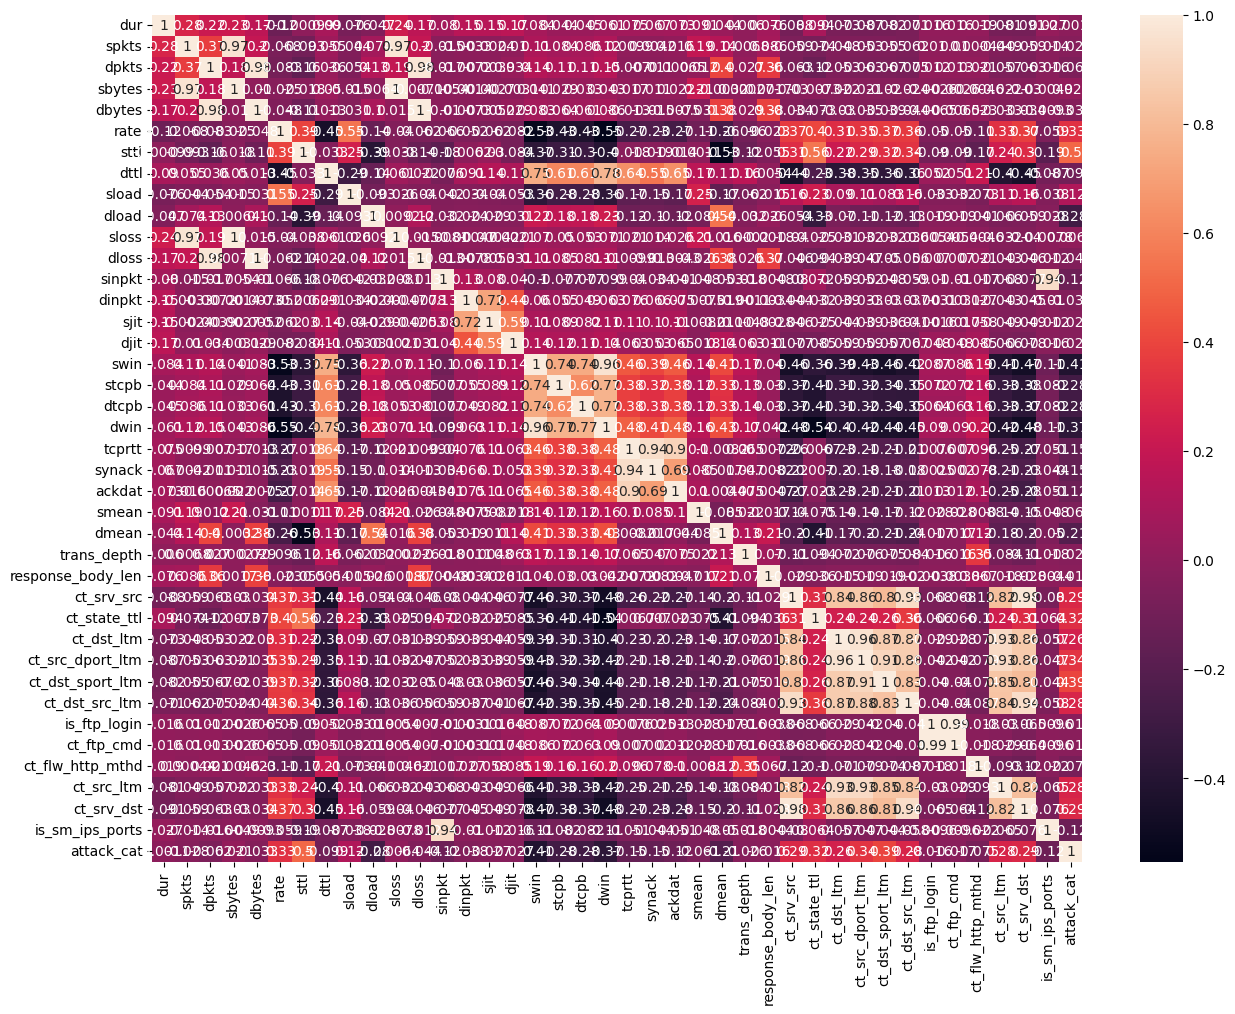

In [51]:
plt.figure(figsize=(15,11))
sns.heatmap(correlation_matrix,annot=True)

In [53]:
df['service'].replace('-',np.NaN,inplace=True)
df['service'].value_counts().sum()

C:\Users\1052\AppData\Local\Temp\ipykernel_10056\413103140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['service'].replace('-',np.NaN,inplace=True)


35179

In [54]:
cateogry_columns=df.select_dtypes(include=['object']).columns.tolist()
integer_columns=df.select_dtypes(include=['int64','float64']).columns.tolist()

for column in df:
    if df[column].isnull().any():
        if(column in cateogry_columns):
            df[column]=df[column].fillna(df[column].mode()[0])
        else:
            df[column]=df[column].fillna(df[column].mean)

In [ ]:
df

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,udp,dns,INT,2,0,496,0,90909.090200,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,udp,dns,INT,2,0,1762,0,125000.000300,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,udp,dns,INT,2,0,1068,0,200000.005100,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,udp,dns,INT,2,0,900,0,166666.660800,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,udp,dns,INT,2,0,2126,0,100000.002500,254,...,2,1,3,0,0,0,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,0.000005,udp,dns,INT,2,0,104,0,200000.005100,254,...,1,1,2,0,0,0,2,1,0,0
82328,1.106101,tcp,dns,FIN,20,8,18062,354,24.410067,254,...,1,1,1,0,0,0,3,2,0,0
82329,0.000000,arp,dns,INT,1,0,46,0,0.000000,0,...,1,1,1,0,0,0,1,1,1,0
82330,0.000000,arp,dns,INT,1,0,46,0,0.000000,0,...,1,1,1,0,0,0,1,1,1,0


In [55]:
encoder = LabelEncoder()
df['service'] = encoder.fit_transform(df['service'])
df['service'].head()

0    1
1    1
2    1
3    1
4    1
Name: service, dtype: int32

In [56]:
df['service'].value_counts()

service
1     68520
4      8287
8      1851
2      1552
3      1396
6       423
10      204
11       30
9        29
0        26
7         9
5         5
Name: count, dtype: int64

In [57]:
df['state'] = encoder.fit_transform(df['state'])
df['state'].head()

0    4
1    4
2    4
3    4
4    4
Name: state, dtype: int32

In [58]:
df['state'].value_counts()

state
3    39339
4    34163
2     6982
5     1842
0        4
6        1
1        1
Name: count, dtype: int64

In [59]:
# df['proto'].value_counts()

In [60]:
df['proto'] = encoder.fit_transform(df['proto'])
df['proto'].head()

0    117
1    117
2    117
3    117
4    117
Name: proto, dtype: int32

In [61]:
df['proto'].value_counts()

proto
111    43095
117    29418
118     3515
6        987
77       676
       ...  
10        32
86        32
126       32
36        31
41        30
Name: count, Length: 131, dtype: int64

In [62]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,117,1,4,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,117,1,4,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,117,1,4,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,117,1,4,2,0,900,0,166666.6608,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,117,1,4,2,0,2126,0,100000.0025,254,...,2,1,3,0,0,0,2,3,0,0


In [63]:
# df.to_csv('newdata.csv')

In [64]:
df['attack_cat'].value_counts()

attack_cat
1    45332
0    37000
Name: count, dtype: int64

In [65]:
x = df.drop(['attack_cat'],axis=1)
y = df['attack_cat']

In [ ]:
# from imblearn.over_sampling import SMOTE

In [ ]:
# oversample = SMOTE()
# x1, y1 = oversample.fit_resample(x, y)

In [66]:
x

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,117,1,4,2,0,496,0,90909.090200,254,...,1,1,1,2,0,0,0,1,2,0
1,0.000008,117,1,4,2,0,1762,0,125000.000300,254,...,1,1,1,2,0,0,0,1,2,0
2,0.000005,117,1,4,2,0,1068,0,200000.005100,254,...,1,1,1,3,0,0,0,1,3,0
3,0.000006,117,1,4,2,0,900,0,166666.660800,254,...,2,2,1,3,0,0,0,2,3,0
4,0.000010,117,1,4,2,0,2126,0,100000.002500,254,...,2,2,1,3,0,0,0,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,0.000005,117,1,4,2,0,104,0,200000.005100,254,...,2,1,1,2,0,0,0,2,1,0
82328,1.106101,111,1,3,20,8,18062,354,24.410067,254,...,2,1,1,1,0,0,0,3,2,0
82329,0.000000,6,1,4,1,0,46,0,0.000000,0,...,1,1,1,1,0,0,0,1,1,1
82330,0.000000,6,1,4,1,0,46,0,0.000000,0,...,1,1,1,1,0,0,0,1,1,1


In [67]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [68]:
x_train.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports'],
      dtype='object')

In [69]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [70]:
pred = dt.predict(x_test)

In [71]:
acc = accuracy_score(y_test,pred)
acc

0.9649797570850203

In [72]:
cls = classification_report(y_test,pred)
print('DecisionTreeClassifier')
print(cls)



DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     11147
           1       0.97      0.97      0.97     13553

    accuracy                           0.96     24700
   macro avg       0.96      0.96      0.96     24700
weighted avg       0.96      0.96      0.96     24700



In [73]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [74]:
pred1 = knn.predict(x_test)

In [75]:
acc1 = accuracy_score(y_test,pred1)
acc1

0.8085425101214575

In [76]:
cls1 = classification_report(y_test,pred1)
print('KNeighborsClassifier')
print(cls1)

KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.78      0.80      0.79     11147
           1       0.83      0.82      0.82     13553

    accuracy                           0.81     24700
   macro avg       0.81      0.81      0.81     24700
weighted avg       0.81      0.81      0.81     24700



In [77]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

c:\Users\1052\.conda\envs\env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [78]:
pred2 = lr.predict(x_test)

In [79]:
acc2 = accuracy_score(y_test,pred2)
acc2

0.7544939271255061

In [80]:
cls2 = classification_report(y_test,pred2)
print('LogisticRegression')
print(cls2)

LogisticRegression
              precision    recall  f1-score   support

           0       0.68      0.86      0.76     11147
           1       0.85      0.67      0.75     13553

    accuracy                           0.75     24700
   macro avg       0.77      0.76      0.75     24700
weighted avg       0.77      0.75      0.75     24700



In [81]:
xg = XGBClassifier()
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [83]:
pred3 = xg.predict(x_test)

In [84]:
acc3 = accuracy_score(y_test,pred3)
acc3

0.9776518218623482

In [85]:
cls3 = classification_report(y_test,pred3)
print('XGBClassifier')
print(cls3)

XGBClassifier
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     11147
           1       0.99      0.97      0.98     13553

    accuracy                           0.98     24700
   macro avg       0.98      0.98      0.98     24700
weighted avg       0.98      0.98      0.98     24700



In [86]:
sv = SVC()
sv.fit(x_train[:1000],y_train[:1000])

SVC()

In [87]:
pred4 = sv.predict(x_test)

In [88]:
acc4 = accuracy_score(y_test,pred4)
acc4

0.6754655870445344

In [89]:
cls4 = classification_report(y_test,pred4)
print('SVC')
print(cls4)

SVC
              precision    recall  f1-score   support

           0       0.63      0.68      0.65     11147
           1       0.72      0.67      0.69     13553

    accuracy                           0.68     24700
   macro avg       0.67      0.68      0.67     24700
weighted avg       0.68      0.68      0.68     24700



In [90]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

In [91]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='softmax'))

In [92]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [93]:
model.fit(x_train, y_train, batch_size=500, epochs=10,validation_data=(x_test, y_test))

Epoch 1/10
116/116 [==============================] - 1s 4ms/step - loss: 3087090.2500 - accuracy: 0.5514 - val_loss: 366276.5938 - val_accuracy: 0.5487
Epoch 2/10
116/116 [==============================] - 0s 3ms/step - loss: 437699.0625 - accuracy: 0.5514 - val_loss: 281402.2188 - val_accuracy: 0.5487
Epoch 3/10
116/116 [==============================] - 0s 3ms/step - loss: 667905.5625 - accuracy: 0.5514 - val_loss: 319679.4375 - val_accuracy: 0.5487
Epoch 4/10
116/116 [==============================] - 0s 3ms/step - loss: 419258.4062 - accuracy: 0.5514 - val_loss: 734354.2500 - val_accuracy: 0.5487
Epoch 5/10
116/116 [==============================] - 0s 3ms/step - loss: 518025.6562 - accuracy: 0.5514 - val_loss: 366665.2812 - val_accuracy: 0.5487
Epoch 6/10
116/116 [==============================] - 0s 3ms/step - loss: 369910.1875 - accuracy: 0.5514 - val_loss: 658486.0000 - val_accuracy: 0.5487
Epoch 7/10
116/116 [==============================] - 0s 3ms/step - loss: 434708.2500 -

In [94]:
abcc=model.predict(x_test)

772/772 [==============================] - 1s 1ms/step


In [95]:
acc5 =accuracy_score(abcc,y_test)
acc5

0.5487044534412956

In [96]:
cls5 = classification_report(y_test,abcc)
print('ANN')
print(cls5)

ANN
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     11147
           1       0.55      1.00      0.71     13553

    accuracy                           0.55     24700
   macro avg       0.27      0.50      0.35     24700
weighted avg       0.30      0.55      0.39     24700



c:\Users\1052\.conda\envs\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\1052\.conda\envs\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\1052\.conda\envs\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [97]:
# model.save('uploads\Ann.h5')

In [163]:
from sklearn.model_selection import train_test_split

# Assume the target column is 'label', change if necessary
X = df.drop('label', axis=1)  # Features
y = df['label']  # Target

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [98]:
graph = pd.DataFrame({'Models':['DecisionTreeClassifier','KNeighborsClassifier','LogisticRegression','XGBoost','SVC','ANN'],'Accuracy':[acc*100,acc1*100,acc2*100,acc3*100,acc4*100,acc5*100]})
graph

,Models,Accuracy
0,DecisionTreeClassifier,96.497976
1,KNeighborsClassifier,80.854251
2,LogisticRegression,75.449393
3,XGBoost,97.765182
4,SVC,67.546559
5,ANN,54.870445


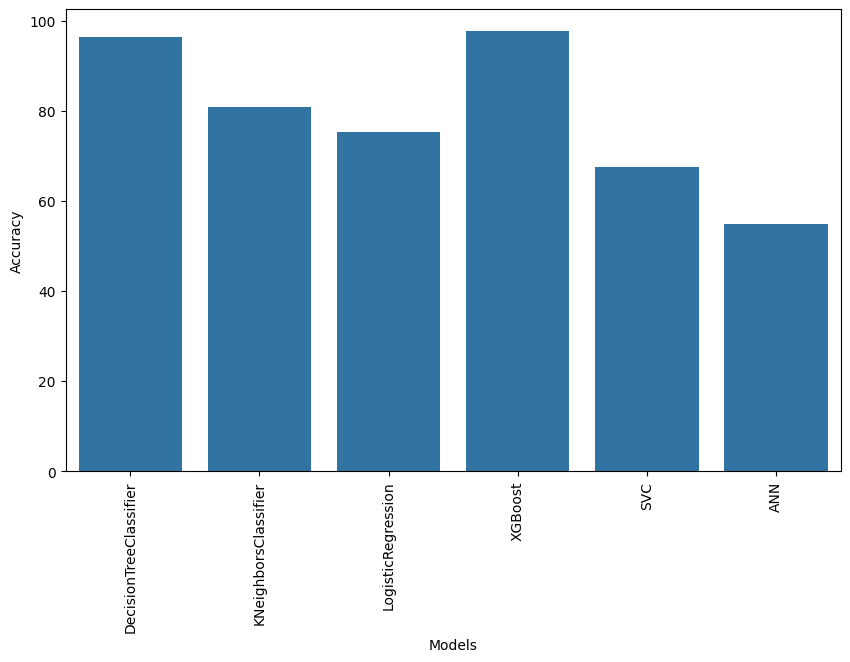

In [99]:
plt.figure(figsize = (10,6))
sns.barplot(y = graph.Accuracy,x = graph.Models)
plt.xticks(rotation = 'vertical')
plt.show()


In [100]:
corr_matrix = df.corr(method = "pearson" )

corr_matrix.style.background_gradient(cmap='coolwarm')

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
dur,1.000000,-0.109279,0.047057,0.009759,0.280239,0.217507,0.225432,0.172492,-0.118031,-0.000986,0.090048,-0.076343,-0.047032,0.240113,0.171182,0.079840,0.150801,0.146599,0.165418,0.083990,0.044482,0.045306,0.061186,0.075329,0.066530,0.073074,0.090527,0.043637,0.006017,0.076215,-0.088328,0.093925,-0.072591,-0.086880,-0.081637,-0.071127,0.015724,0.015547,0.018879,-0.080789,-0.091253,0.027472,-0.001145
proto,-0.109279,1.000000,0.034843,-0.126237,0.006986,0.013783,0.003154,0.007791,0.016812,0.068657,0.077113,0.009981,0.027953,0.006517,0.010036,-0.574409,-0.075156,0.009310,0.004807,0.092872,0.069114,0.068840,0.089179,0.042720,0.036594,0.042901,0.036395,0.047422,0.015390,0.003714,0.150077,-0.084815,0.143142,0.131259,0.109692,0.139494,0.008052,0.008031,0.018004,0.130915,0.152007,-0.585578,-0.003497
service,0.047057,0.034843,1.000000,-0.214796,0.127240,0.101380,0.100080,0.053799,-0.210319,-0.338761,0.299813,-0.135425,-0.055452,0.112271,0.073134,-0.042252,-0.010217,-0.002832,0.086309,0.363466,0.293380,0.290910,0.378684,0.098645,0.067681,0.120696,0.287221,0.210330,0.280310,0.068925,-0.269472,-0.233593,-0.162031,-0.173395,-0.170041,-0.195763,0.026724,0.026653,0.329692,-0.179125,-0.258621,-0.040875,0.000528
state,0.009759,-0.126237,-0.214796,1.000000,-0.083151,-0.099018,-0.039669,-0.056633,0.542535,0.607395,-0.562248,0.342532,-0.170544,-0.055355,-0.071568,0.093296,-0.087680,-0.072166,-0.089977,-0.542109,-0.493853,-0.494439,-0.638506,-0.397741,-0.351242,-0.385886,-0.102934,-0.309699,-0.097707,-0.026685,0.457256,0.697962,0.365987,0.383399,0.411372,0.453192,-0.051189,-0.051245,-0.114441,0.380559,0.456696,0.099622,0.459040
spkts,0.280239,0.006986,0.127240,-0.083151,1.000000,0.369554,0.965750,0.198324,-0.068249,-0.092536,0.054601,-0.044194,0.074440,0.973644,0.198683,-0.014501,-0.003309,-0.002407,0.010481,0.111828,0.083647,0.086208,0.116206,0.009943,0.004203,0.015534,0.193038,0.140961,0.006767,0.085618,-0.058717,-0.073850,-0.047928,-0.053109,-0.055095,-0.061852,0.010361,0.010423,0.000443,-0.049367,-0.058815,-0.013960,-0.027731
dpkts,0.217507,0.013783,0.101380,-0.099018,0.369554,1.000000,0.175834,0.976419,-0.083173,-0.163830,0.036483,-0.054145,0.133835,0.189060,0.981506,-0.017141,-0.007181,-0.003862,0.034276,0.141478,0.110259,0.107270,0.147482,-0.007023,-0.010998,-0.000646,0.012490,0.395965,0.026651,0.358040,-0.062836,-0.122442,-0.052606,-0.062549,-0.067452,-0.075012,0.012473,0.012555,0.021041,-0.057374,-0.063169,-0.016103,-0.061515
sbytes,0.225432,0.003154,0.100080,-0.039669,0.965750,0.175834,1.000000,0.010036,-0.025102,-0.017866,0.049891,-0.015228,-0.006428,0.995027,0.007091,-0.005399,-0.001432,-0.002675,-0.003050,0.041450,0.028712,0.033089,0.043252,0.016774,0.010659,0.021615,0.206682,-0.003185,0.000271,0.001684,-0.030204,-0.007311,-0.022276,-0.020586,-0.020451,-0.024065,-0.002572,-0.002569,-0.004626,-0.021540,-0.030049,-0.004910,0.020641
dbytes,0.172492,0.007791,0.053799,-0.056633,0.198324,0.976419,0.010036,1.000000,-0.047978,-0.114537,0.012537,-0.031266,0.100923,0.014561,0.997109,-0.010201,-0.007266,-0.005182,0.029201,0.083015,0.064456,0.061270,0.086472,-0.012606,-0.014792,-0.007524,-0.030533,0.375397,0.028519,0.382727,-0.034330,-0.073023,-0.029569,-0.035335,-0.038965,-0.044048,-0.006521,-0.006498,0.022901,-0.033301,-0.034416,-0.009267,-0.032632
rate,-0.118031,0.016812,-0.210319,0.542535,-0.068249,-0.083173,-0.025102,-0.047978,1.000000,0.388155,-0.453913,0.550104,-0.138441,-0.040139,-0.062073,-0.065681,-0.052206,-0.061961,-0.081591,-0.534075,-0.428528,-0.426959,-0.553097,-0.267190,-0.228876,-0.268328,-0.109797,-0.259278,-0.096055,-0.023166,0.367670,0.399469,0.310987,0.345573

In [101]:
x_train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
519,1.565097,111,4,3,60,348,2976,449181,260.047784,62,...,1,1,1,1,0,0,1,2,1,0
9536,59.944077,111,8,2,10646,1582,14355774,68026,203.973448,254,...,1,2,1,1,0,0,0,3,1,0
75180,0.000003,111,1,5,2,0,90,0,333333.321500,254,...,3,1,1,6,0,0,0,4,6,0
60163,0.000002,51,1,4,2,0,86,0,500000.001300,254,...,6,2,2,2,0,0,0,5,2,0
8737,45.037312,77,1,4,42,0,18480,0,0.910356,254,...,1,1,1,1,0,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0.263156,111,4,3,10,8,794,2884,64.600466,62,...,1,1,1,1,0,0,1,6,1,0
54886,1.960670,111,4,3,152,34,195881,11000,94.355501,254,...,1,1,1,1,0,0,0,2,1,0
76820,0.488035,111,1,3,10,6,534,268,30.735501,254,...,1,1,1,4,0,0,0,1,4,0
860,1.211704,111,4,3,10,8,746,354,14.029829,254,...,1,1,1,1,0,0,1,1,1,0


In [102]:
df[df['attack_cat']==1]

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
243,0.921987,77,1,4,20,0,1280,0,20.607666,254,...,1,1,2,0,0,0,1,1,0,1
244,0.921987,77,1,4,20,0,1280,0,20.607666,254,...,1,1,2,0,0,0,1,1,0,1
245,0.921987,77,1,4,20,0,1280,0,20.607666,254,...,1,1,2,0,0,0,1,1,0,1
246,0.921987,77,1,4,20,0,1280,0,20.607666,254,...,1,1,2,0,0,0,1,1,0,1
247,0.000009,95,1,4,2,0,104,0,111111.107200,254,...,1,1,2,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65847,0.000012,117,1,4,2,0,1510,0,83333.330390,254,...,1,1,1,0,0,0,1,5,0,1
65848,20.542910,117,1,4,4,0,1216,0,0.146036,254,...,1,1,1,0,0,0,1,6,0,1
65849,20.542910,117,1,4,4,0,1216,0,0.146036,254,...,1,1,1,0,0,0,1,6,0,1
65850,0.627022,111,1,3,10,6,590,268,23.922605,254,...,1,1,1,0,0,0,1,5,0,1


In [103]:
a = [[0.921987,77,1,4,20,0,1280,0,20.607666,254,0,180363632,0,0,0,0.011,0,0,0,0,0,0,0,0,0,0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,1,0]]
b = dt.predict(a)
b

c:\Users\1052\.conda\envs\env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0], dtype=int64)